In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("C:/Users/jaska/OneDrive/Desktop/VS_Code_Program/Python/Datasets/House Price/data.csv")

In [3]:
df=df.iloc[:,1:]
df=df.drop(columns=["street","country"],axis=1)
df["yr_built"]=2026 - df["yr_built"]

In [4]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,71,2005,Shoreline,WA 98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,105,0,Seattle,WA 98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,60,0,Kent,WA 98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,63,0,Bellevue,WA 98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,50,1992,Redmond,WA 98052


In [5]:
df.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
city             0
statezip         0
dtype: int64

extra

<Axes: >

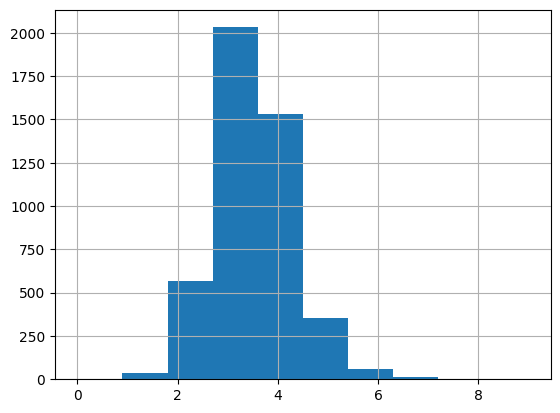

In [6]:
df["bedrooms"].hist()

In [11]:
import pandas as pd

corr = df.corr(numeric_only=True)

print(corr["price"].sort_values(ascending=False))

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built        -0.021857
yr_renovated    -0.028774
Name: price, dtype: float64


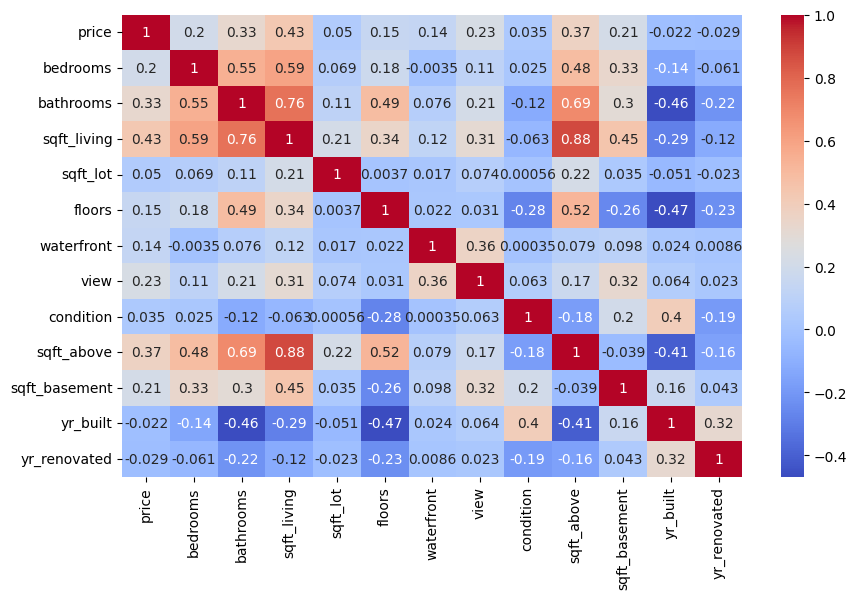

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True ,cmap="coolwarm")
plt.show()

In [20]:
df["price"].skew()

np.float64(24.790932561757053)

Extra

In [22]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,71,2005,Shoreline,WA 98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,105,0,Seattle,WA 98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,60,0,Kent,WA 98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,63,0,Bellevue,WA 98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,50,1992,Redmond,WA 98052


In [23]:
df["statezip"]=df["statezip"].str.split(" ").str[-1]

In [24]:
df["renovate"]=(df["yr_renovated"]>0).astype(int)
df=df.drop(["yr_renovated"],axis=1)

In [25]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,city,statezip,renovate
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,71,Shoreline,98133,1
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,105,Seattle,98119,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,60,Kent,98042,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,63,Bellevue,98008,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,50,Redmond,98052,1


In [26]:
df["price"].describe()

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

In [27]:
df=df[(df["price"] < 300000) & (df["price"] > 50000)]
df["price"].describe()

count       890.000000
mean     234784.592372
std       45936.663466
min       80000.000000
25%      210000.000000
50%      245000.000000
75%      269800.000000
max      299995.000000
Name: price, dtype: float64

STEP 1: TRAIN TEST SPLIT

In [28]:
X=df.iloc[:,1:]
y=np.log(df["price"])

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

ENCODING CATEGORIAL DATA

In [30]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer(transformers=[
    ("One",OneHotEncoder(drop="first",handle_unknown="ignore"),["city"])
],remainder="passthrough")

In [31]:
X_train=ct.fit_transform(X_train)
X_test=ct.transform(X_test)

C:\Users\jaska\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [32]:
X_train=X_train.toarray()
X_test=X_test.toarray()

In [33]:
X_train=pd.DataFrame(X_train,columns=[name.split("__")[-1] for name in ct.get_feature_names_out()])
X_test=pd.DataFrame(X_test,columns=[name.split("__")[-1] for name in ct.get_feature_names_out()])

In [34]:
X_train.columns

Index(['city_Auburn', 'city_Bellevue', 'city_Black Diamond', 'city_Burien',
       'city_Carnation', 'city_Covington', 'city_Des Moines', 'city_Duvall',
       'city_Enumclaw', 'city_Fall City', 'city_Federal Way', 'city_Issaquah',
       'city_Kenmore', 'city_Kent', 'city_Kirkland', 'city_Lake Forest Park',
       'city_Maple Valley', 'city_Medina', 'city_Milton', 'city_Normandy Park',
       'city_North Bend', 'city_Pacific', 'city_Ravensdale', 'city_Redmond',
       'city_Renton', 'city_Sammamish', 'city_SeaTac', 'city_Seattle',
       'city_Shoreline', 'city_Skykomish', 'city_Snoqualmie', 'city_Tukwila',
       'city_Vashon', 'city_Woodinville', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'sqft_above', 'sqft_basement', 'yr_built', 'statezip', 'renovate'],
      dtype='object')

FEATURE SCALLING FOR LINEAR REGRESSION

In [35]:
ct_lr=ColumnTransformer(transformers=[
    ("ss",StandardScaler(),["sqft_living","sqft_lot","sqft_above","yr_built","sqft_basement","statezip"])
],remainder="passthrough")

In [36]:
X_train_lr=ct_lr.fit_transform(X_train)
X_test_lr=ct_lr.transform(X_test)

In [37]:
X_train_lr=pd.DataFrame(X_train_lr,columns=[name.split("__")[-1] for name in ct_lr.get_feature_names_out()])
X_test_lr=pd.DataFrame(X_test_lr,columns=[name.split("__")[-1] for name in ct_lr.get_feature_names_out()])

LINEAR REGRESSION

In [67]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_lr,y_train)
pred=np.exp(lr.predict(X_test_lr))

RANDOM FOREST

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
para={
    "n_estimators":[10,50,100,150],
    "max_depth":[None,10,20,30],
    "min_samples_split":[2,5,10]
}
rf=RandomForestRegressor()

gs=GridSearchCV(estimator=rf,param_grid=para,cv=5,scoring="neg_mean_squared_error",)
gs.fit(X_train,y_train)
pred_2=np.exp(gs.predict(X_test))

In [40]:
print(gs.best_estimator_)

RandomForestRegressor(max_depth=20, min_samples_split=10, n_estimators=50)


GRADIENT BOOSTING

In [41]:
from sklearn.ensemble import GradientBoostingRegressor
gb=GradientBoostingRegressor()
gradient_para={
    "n_estimators":[10,50,100,150],
    "learning_rate":[1,0.5,0.1,0.01]
}
gs_gradient=GridSearchCV(estimator=gb,param_grid=gradient_para,cv=5,scoring="neg_mean_squared_error",)
gs_gradient.fit(X_train,y_train)
pred_3=np.exp(gs_gradient.predict(X_test))

In [42]:
print(gs_gradient.best_estimator_)

GradientBoostingRegressor(n_estimators=50)


XGBOOST

In [43]:
from xgboost import XGBRegressor
xg=XGBRegressor()

xg_para={
    "n_estimators":[10,50,100,150],
    "learning_rate":[1,0.5,0.1,0.01],
    "max_depth":[2,6,8,10,15]
}

gs_xg=GridSearchCV(estimator=xg,param_grid=xg_para,cv=5,scoring="neg_mean_squared_error")
gs_xg.fit(X_train,y_train)
pred_4=np.exp(gs_xg.predict(X_test))

In [44]:
print(gs_xg.best_params_)

{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}


CATBOOST

In [45]:
from catboost import CatBoostRegressor

cat_param = {
    "iterations":[200,500],
    "depth":[4,6,8],
    "learning_rate":[0.01,0.05,0.1],
    "l2_leaf_reg":[1,3,5]
}

cat = CatBoostRegressor(verbose=0)

gs_cat = GridSearchCV(estimator=cat,param_grid=cat_param,cv=5,scoring="neg_mean_squared_error")
gs_cat.fit(X_train,y_train)
pred_5=np.exp(gs_cat.predict(X_test))

In [46]:
gs_cat.best_params_

{'depth': 4, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.05}

ROOT MEAN SQUARE ERROR

In [69]:
from sklearn.metrics import mean_squared_error

lrpred=np.sqrt(mean_squared_error(y_test,pred))
rfpred=np.sqrt(mean_squared_error(y_test,pred_2))
gbpred=np.sqrt(mean_squared_error(y_test,pred_3))
xgbpred=np.sqrt(mean_squared_error(y_test,pred_4))
catpred=np.sqrt(mean_squared_error(y_test,pred_5))

In [70]:
print("Root Mean Square Error(Linear Regression) : ",lrpred)
print("Root Mean Square Error(Random Forest) : ",rfpred)
print("Root Mean Square Error(Gradient Boosting) : ",gbpred)
print("Root Mean Square Error(Extreme Gradient Boosting) : ",xgbpred)
# print("Root Mean Square Error(LIGHT Gradient Boosting) : ",np.sqrt(mean_squared_error(y_test,pred_5)))
print("Root Mean Square Error(CAT Gradient Boosting) : ",catpred)

Root Mean Square Error(Linear Regression) :  232568.72717382683
Root Mean Square Error(Random Forest) :  0.22417588632755195
Root Mean Square Error(Gradient Boosting) :  0.2311290088340985
Root Mean Square Error(Extreme Gradient Boosting) :  0.22448070635054318
Root Mean Square Error(CAT Gradient Boosting) :  0.2233320645141579


VISUAL REPRESENTATION OF ROOT MEAN SQUARE ERROR

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Linear Reg.'),
  Text(1, 0, 'Random Forest'),
  Text(2, 0, 'Grad. Boost'),
  Text(3, 0, 'XGBoost'),
  Text(4, 0, 'CatBoost')])

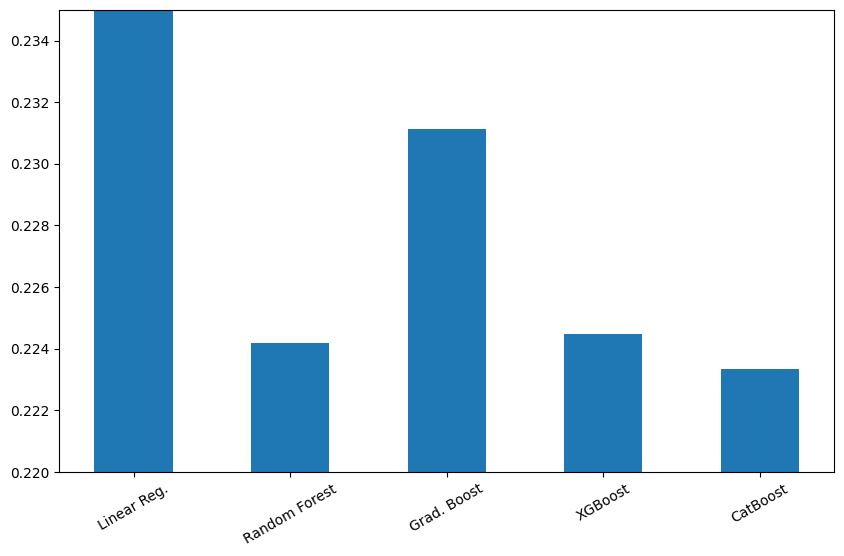

In [79]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

model=["Linear Regression","Random Forest","Gardient Boosting","XGBoost","CATBoost"]
rmse=[lrpred,rfpred,gbpred,xgbpred,catpred]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(models, rmse, edgecolor='none', width=0.5)
plt.ylim(0.22,0.235)
plt.xticks(rotation=30)

